Importing the Required Libraries

In [10]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from IPython.display import display

Building the Circuit

In [2]:
qubits = QuantumRegister(1, "q")
clbits = ClassicalRegister(2, "c")
circuit = QuantumCircuit(qubits, clbits)
(q0,) = qubits
(c0, c1) = clbits

Apply a Hadamard gate to create superposition:

In [3]:
circuit.h(q0)

Measure the qubit and store the result in the first classical bit:

In [4]:
circuit.measure(q0, c0)

Now comes the dynamic part. If the measurement result is 1, we apply an X gate to flip the qubit back to 0:

In [5]:
with circuit.if_test((c0, 1)):
    circuit.x(q0)

Finally, measure the qubit again and store the result in the second classical bit:

In [6]:
circuit.measure(q0, c1)

Visualizing the Circuit

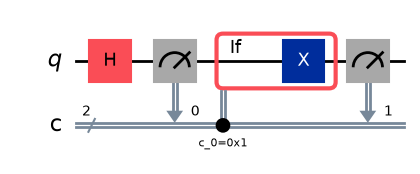

In [7]:
circuit.draw("mpl")

Running the Simulation

In [8]:
simulator = AerSimulator()
job = simulator.run(circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit)
print(counts)

{'00': 516, '01': 508}


Complete Code

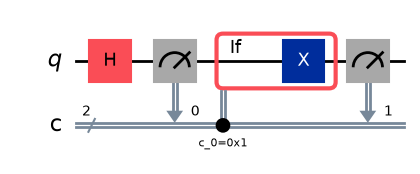

{'01': 512, '00': 512}


In [11]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

qubits = QuantumRegister(1, "q")
clbits = ClassicalRegister(2, "c")
circuit = QuantumCircuit(qubits, clbits)
(q0,) = qubits
(c0, c1) = clbits

circuit.h(q0)
circuit.measure(q0, c0)

with circuit.if_test((c0, 1)):
    circuit.x(q0)

circuit.measure(q0, c1)

display(circuit.draw("mpl"))

simulator = AerSimulator()
job = simulator.run(circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit)
print(counts)